# 04 - Out-of-Sample Volatility Model Validation

Research notebook only. Runs the walk-forward comparison in `askgene_quant.validation.backtest` across rolling historical volatility, EWMA, and GARCH(1,1) on real ETH/USD data, and reports RMSE and QLIKE against the squared-return realized-variance proxy. Every forecast for day *t* uses only information available through day *t-1* - see `docs/model_validation.md` for the full write-up.

In [1]:
import sys
from pathlib import Path

QUANT_SRC = Path("../quant/src").resolve()
sys.path.insert(0, str(QUANT_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from askgene_quant.config import DEFAULT_VOLATILITY_SETTINGS as settings
from askgene_quant.data.loader import load_market_data
from askgene_quant.data.quality import check_data_quality
from askgene_quant.data.returns import log_returns

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ASSET = "ETH-USD"
ohlcv = load_market_data(ASSET, cache_dir=(QUANT_SRC.parent / "data_cache"))
report = check_data_quality(ohlcv)
print(f"{len(ohlcv)} daily candles, {ohlcv.index.min().date()} -> {ohlcv.index.max().date()}")
print("quality errors:", report.errors or "none")
print(f"quality warnings: {len(report.warnings)}")
for w in report.warnings:
    print(" -", w)

returns = log_returns(ohlcv["close"])
print(f"\n{len(returns)} daily log returns")


3788 daily candles, 2016-05-18 -> 2026-10-02
quality errors: none
quality warnings: 2
 - 2 missing date(s) in expected D calendar between 2016-05-18 and 2026-10-02
 - 1 day(s) with |log return| > 0.5: 2020-03-12

3787 daily log returns


In [2]:
from askgene_quant.validation.backtest import run_volatility_backtest

result = run_volatility_backtest(returns, settings=settings, oos_fraction=0.3)
print(f"Out-of-sample period: {result.oos_start.date()} -> {result.oos_end.date()} "
      f"({result.n_oos} observations)")

Out-of-sample period: 2023-08-23 -> 2026-10-02 (1137 observations)


## Forecast accuracy: RMSE and QLIKE

In [3]:
metrics_df = pd.DataFrame(result.metrics).T.sort_values("qlike")
metrics_df

,rmse,qlike
garch,0.002909,-5.752675
ewma,0.002911,-5.678415
rolling_hist_vol,0.002931,-5.633211


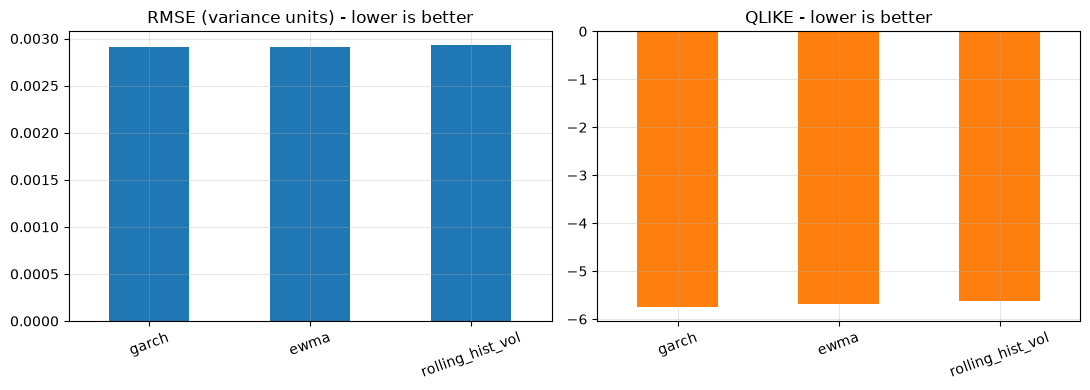

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics_df["rmse"].plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].set_title("RMSE (variance units) - lower is better")
axes[0].tick_params(axis="x", rotation=20)
metrics_df["qlike"].plot(kind="bar", ax=axes[1], color="#ff7f0e")
axes[1].set_title("QLIKE - lower is better")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

QLIKE is the more standard metric for comparing variance forecasts (it penalizes under-prediction more heavily and is robust to the choice of volatility proxy); GARCH ranking best on QLIKE while staying competitive on RMSE is the expected result given it's the only model here with both a shock-reaction term (`alpha`) and mean-reverting persistence (`beta`).

## Forecasts vs. realized variance proxy over the OOS window

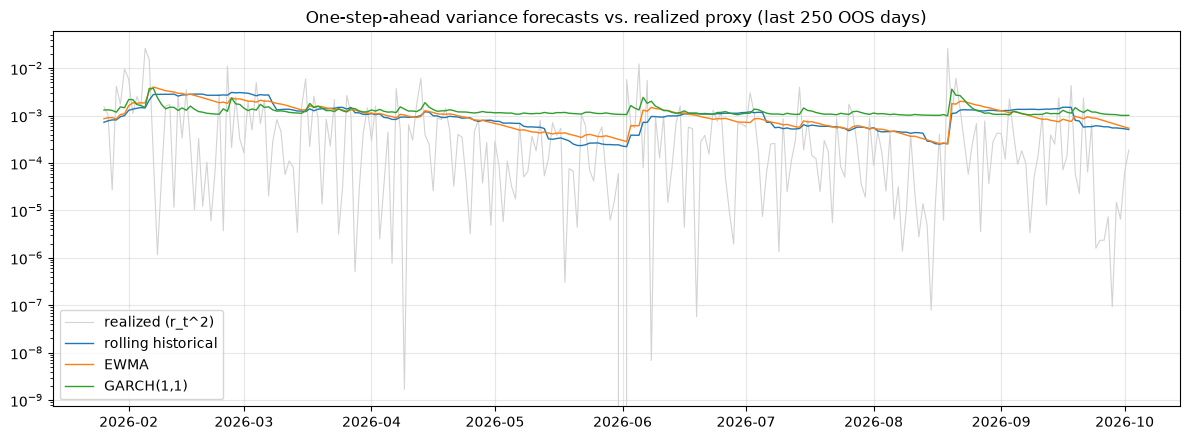

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
window = result.forecasts.iloc[-250:]
ax.plot(window.index, window["proxy"], color="lightgray", lw=0.8, label="realized (r_t^2)")
ax.plot(window.index, window["rolling_hist_vol"], lw=1, label="rolling historical")
ax.plot(window.index, window["ewma"], lw=1, label="EWMA")
ax.plot(window.index, window["garch"], lw=1, label="GARCH(1,1)")
ax.set_yscale("log")
ax.set_title("One-step-ahead variance forecasts vs. realized proxy (last 250 OOS days)")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

- All three models track the broad level of realized variance; GARCH and EWMA both adapt to shocks within a day or two, while rolling historical volatility lags and shows step changes as old observations exit the window.
- GARCH(1,1) achieves the best (lowest) QLIKE, consistent with it being the only estimator with both a reactive and a mean-reverting component.
- No model uses information from the day it's being scored against - see `rolling_variance_forecast`, `ewma_variance_forecast`, and `garch_walk_forward_forecast` in `askgene_quant.validation.backtest` for exactly how each forecast is shifted/seeded to avoid look-ahead.